<a href="https://colab.research.google.com/github/alkezzar/Homework1/blob/main/DE_IP_2024_Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Наложение и удаление шума

In [ ]:
image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

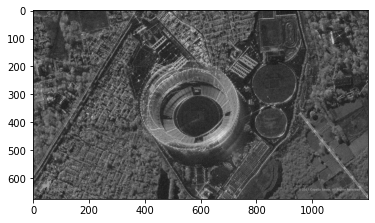

In [ ]:
plt.imshow(image_gray, cmap="gray")

In [ ]:
# Gaussian noise
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

array([[229,   0,   0, ...,   0,   0,   0],
       [126,  68,   0, ...,   0,   0,  32],
       [162,  11,   6, ...,  13,  50,   0],
       ...,
       [  0,   6, 141, ...,   0,   0, 105],
       [ 26,   0,   0, ...,  54,  99,   0],
       [ 30,   0,  14, ...,   0,  84,   0]], dtype=uint8)

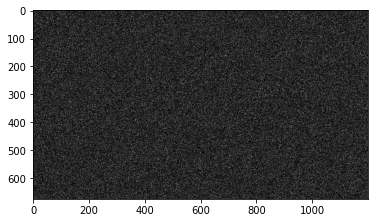

In [ ]:
plt.imshow(noise_gauss, cmap="gray")

In [ ]:
# Salt and pepper
noise =  np.random.randint(0, 101, size = (image_gray.shape[0], image_gray.shape[1]), dtype=int)
zeros_pixel = np.where(noise == 0)
ones_pixel = np.where(noise == 100)

In [ ]:
bg_image = np.ones(image_gray.shape, np.uint8) * 128

In [ ]:
bg_image[zeros_pixel] = 0
bg_image[ones_pixel] = 255

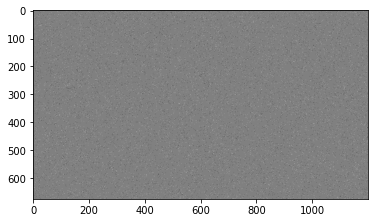

In [ ]:
plt.imshow(bg_image, cmap="gray")

In [ ]:
image_noise_gauss = cv2.add(image_gray,noise_gauss)

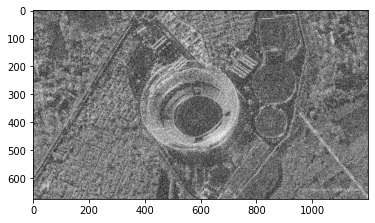

In [ ]:
plt.imshow(image_noise_gauss, cmap="gray")

In [ ]:
from skimage.metrics import structural_similarity, mean_squared_error
mse_gauss = mean_squared_error(image_gray, image_noise_gauss)
(ssim, diff) = structural_similarity(image_gray, image_noise_gauss, full=True)
print(mse_gauss, ssim)

4239.23434691358 0.18694949978788222


In [ ]:
image_gauss_median = cv2.medianBlur(image_noise_gauss, 3)

In [ ]:
mse_gauss_median = mean_squared_error(image_gray, image_gauss_median)
(ssim_gauss_median, diff) = structural_similarity(image_gray,  image_gauss_median, full=True)

In [ ]:
print(mse_gauss_median, ssim_gauss_median)

1034.030974074074 0.42729854374617976


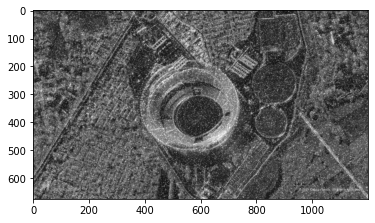

In [ ]:
plt.imshow(image_gauss_median, cmap="gray")

In [ ]:
import copy

image_sp = copy.deepcopy(image_gray)

image_sp[zeros_pixel] = 0
image_sp[ones_pixel] = 255

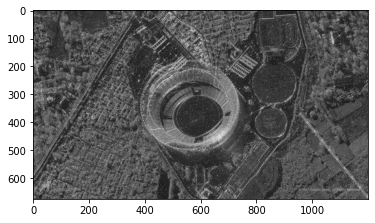

In [ ]:
plt.imshow(image_sp, cmap="gray")

In [ ]:
mse_sp = mean_squared_error(image_gray, image_sp)
(ssim_sp, diff) = structural_similarity(image_gray, image_sp, full=True)
print(mse_sp, ssim_sp)

387.02924320987654 0.7229272028218258


In [ ]:
image_sp_median = cv2.medianBlur(image_sp, 3)

In [ ]:
mse_sp_median = mean_squared_error(image_gray, image_sp_median)
(ssim_sp_median, diff) = structural_similarity(image_gray, image_sp_median, full=True)
print(mse_sp_median, ssim_sp_median)

95.94404444444444 0.8160796293211554


# Другие типы фильтров

In [ ]:
image_gauss_gauss = cv2.GaussianBlur(image_noise_gauss,(5,5),0)

In [ ]:
image_gauss_bilat = cv2.bilateralFilter(image_noise_gauss,9,75,75)

In [ ]:
image_gauss_nlm = cv2.fastNlMeansDenoising(image_noise_gauss, h = 20)

In [ ]:
import math

def geom(a):
    prod = 1
    for i in range(a.shape[0]):
        prod1 = 1
        for j in range(a.shape[1]):
            prod1 *= a[i,j]
        prod1 = math.pow(prod1, 1.0/9.0)
        prod *= prod1
    return prod

def proc(img, filter):
    img_res = copy.deepcopy(img)
    for i in range(0,img.shape[0] -2):
        for j in range(0,img.shape[1] -2):
            img_res[i:i+3, j:j+3] = filter(img[i:i+3, j:j+3])
    return img_res

res = proc(image_noise_gauss, geom)


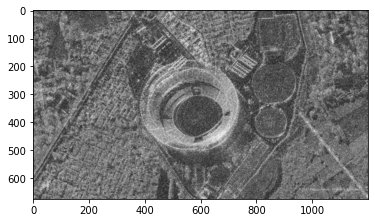

In [ ]:
plt.imshow(res, cmap="gray")

In [ ]:
mse_geom = mean_squared_error(image_gray, res)
(ssim_geom, diff) = structural_similarity(image_gray, res, full=True)
print(mse_geom, ssim_geom)

1219.7879691358025 0.3984170557811386



# 2D свертка

In [ ]:
# averaging filter
kernel_5 = np.ones((5,5),np.float32)/25
image_k5 = cv2.filter2D(image_gray,-1,kernel_5)
# blured_image = cv2.blur(img,(5,5))
image_b5 = cv2.blur(image_gray,(5,5))

In [ ]:
mse_kb = mean_squared_error(image_k5, image_b5)
(ssim_kb, diff) = structural_similarity(image_k5, image_b5, full=True)
print(mse_kb, ssim_kb)

0.0 1.0


In [ ]:
# Laplasian
kernel_lapl = np.array([[0,-10,0],
                        [-10,40,-10],
                        [0,-10,0]], np.float32)

In [ ]:
image_lapl = cv2.filter2D(image_gray,-1,kernel_lapl)

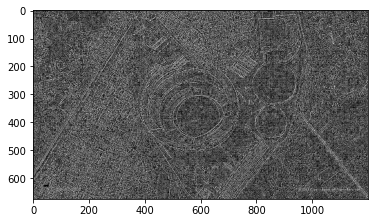

In [ ]:
plt.imshow(image_lapl, cmap="gray")

In [ ]:
# ДЗ 2
# Зашумить изображение при помощи шума гаусса, постоянного шума.
# Протестировать медианный фильтр, фильтр гаусса, билатериальный фильтр, фильтр нелокальных средних с различными параметрами.
# Выяснить, какой фильтр показал лучший результат фильтрации шума.

Результаты фильтрации шума Гаусса:
Гаусс (3x3, 1.0): PSNR = 25.57, MSE = 180.38
Гаусс (7x7, 2.0): PSNR = 24.50, MSE = 230.88
Билатеральный (d=5): PSNR = 24.70, MSE = 220.17
Билатеральный (d=9): PSNR = 24.93, MSE = 209.13
NLM (h=7): PSNR = 18.89, MSE = 839.14
NLM (h=15): PSNR = 19.32, MSE = 761.13
Лучший для шума Гаусса: Гаусс (3x3, 1.0)

Результаты фильтрации постоянного (равномерного) шума:
Медианный (3x3): PSNR = 23.33, MSE = 302.38
Медианный (5x5): PSNR = 23.66, MSE = 279.75
Лучший для постоянного шума: Медианный (5x5)


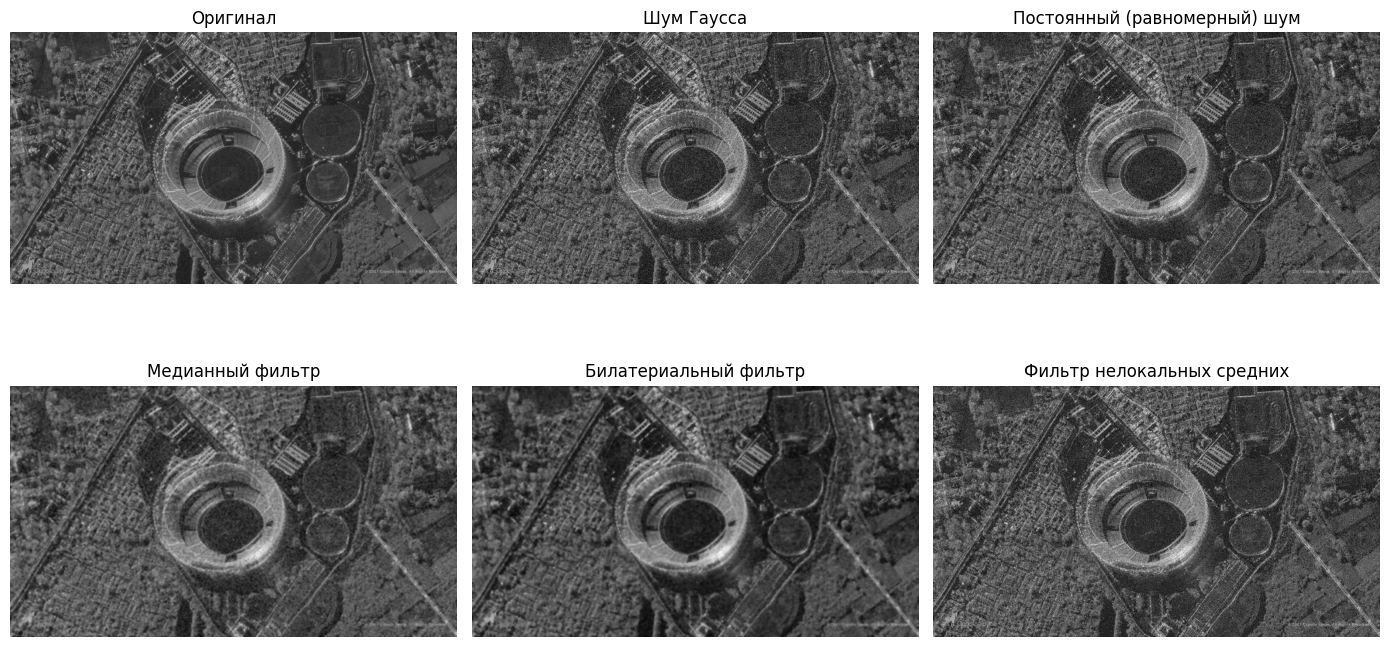

In [7]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

image = cv2.imread('/content/sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

mean = 0
stddev = 30
noise_gauss = np.random.normal(mean, stddev, image_gray.shape).astype(np.int16)
image_gauss = np.clip(image_gray.astype(np.int16) + noise_gauss, 0, 255).astype(np.uint8)

noise_uniform = np.random.uniform(-50, 50, image_gray.shape).astype(np.int16)
image_uniform = np.clip(image_gray.astype(np.int16) + noise_uniform, 0, 255).astype(np.uint8)

median_1 = cv2.medianBlur(image_uniform, 3)
median_2 = cv2.medianBlur(image_uniform, 5)

gauss_1 = cv2.GaussianBlur(image_gauss, (3, 3), 1.0)
gauss_2 = cv2.GaussianBlur(image_gauss, (7, 7), 2.0)

bilateral_1 = cv2.bilateralFilter(image_gauss, d=5, sigmaColor=50, sigmaSpace=50)
bilateral_2 = cv2.bilateralFilter(image_gauss, d=9, sigmaColor=75, sigmaSpace=75)

nl_means_1 = cv2.fastNlMeansDenoising(image_gauss, h=7, templateWindowSize=7, searchWindowSize=21)
nl_means_2 = cv2.fastNlMeansDenoising(image_gauss, h=15, templateWindowSize=7, searchWindowSize=21)

def evaluate_filters(original, filtered_dict):
    results = {}
    for name, img in filtered_dict.items():
        mse = np.mean((original.astype(np.float64) - img.astype(np.float64)) ** 2)
        psnr = cv2.PSNR(original, img)
        results[name] = {'MSE': mse, 'PSNR': psnr}
    return results

gauss_results = {
    'Гаусс (3x3, 1.0)': gauss_1,
    'Гаусс (7x7, 2.0)': gauss_2,
    'Билатеральный (d=5)': bilateral_1,
    'Билатеральный (d=9)': bilateral_2,
    'NLM (h=7)': nl_means_1,
    'NLM (h=15)': nl_means_2
}

uniform_results = {
    'Медианный (3x3)': median_1,
    'Медианный (5x5)': median_2
}

g_metrics = evaluate_filters(image_gray, gauss_results)
u_metrics = evaluate_filters(image_gray, uniform_results)

best_gauss = max(g_metrics, key=lambda x: g_metrics[x]['PSNR'])
best_uniform = max(u_metrics, key=lambda x: u_metrics[x]['PSNR'])

print("Результаты фильтрации шума Гаусса:")
for name, metrics in g_metrics.items():
    print(f"{name}: PSNR = {metrics['PSNR']:.2f}, MSE = {metrics['MSE']:.2f}")
print(f"Лучший для шума Гаусса: {best_gauss}\n")

print("Результаты фильтрации постоянного (равномерного) шума:")
for name, metrics in u_metrics.items():
    print(f"{name}: PSNR = {metrics['PSNR']:.2f}, MSE = {metrics['MSE']:.2f}")
print(f"Лучший для постоянного шума: {best_uniform}")

# Визуализация 6 основных изображений (оригинал, шумы и основные фильтры)
plt.figure(figsize=(14, 8))

plt.subplot(2, 3, 1)
plt.title("Оригинал")
plt.imshow(image_gray, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.title("Шум Гаусса")
plt.imshow(image_gauss, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.title("Постоянный (равномерный) шум")
plt.imshow(image_uniform, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.title("Медианный фильтр")
plt.imshow(median_2, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.title("Билатериальный фильтр")
plt.imshow(bilateral_2, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.title("Фильтр нелокальных средних")
plt.imshow(nl_means_2, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()